<br><br><br>
<font>
<div dir=ltr align=center>
<img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width=150 height=150>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Artificial Intelligence <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Spring 2026<br>
<font color=3C99D size=5>
    Neural Network<br>
<font color=696880 size=4>
    Iliya Forsati

Name: `Arvin Baghal Asl`

SID: `403105793`

## What is a Neuron?

The human brain is arguably the most complex structure in the known universe, consisting of approximately 86 billion nerve cells called **Neurons**. A single neuron is a relatively simple processing unit on its own, but human reasoning, memory, and learning emerge from the massive, interconnected web of these cells.

To understand artificial neural networks, we first need to look at the biological inspiration. A biological neuron consists of three main components:
* **Dendrites:** Branch-like structures that act as the network's receivers. They collect electrical signals (information) from other connected neurons.
* **Soma (Cell Body):** The core processor of the cell. It aggregates all the incoming signals from the dendrites.
* **Axon:** The output cable. If the total accumulated signal in the soma exceeds a certain biological threshold, the neuron "fires," sending an electrical spike (action potential) down the axon to pass the information to the next set of neurons.

---

## Can we implement it in computers?

Yes! In 1957, a psychologist named Frank Rosenblatt, inspired by this biological mechanism, invented a mathematical and computational model called the **Perceptron**. The perceptron is the foundational building block of all modern Artificial Neural Networks.

To bring the biological neuron into the realm of computer science, we must translate its biological parts into mathematical operations:

1. **Inputs and Weights (The Dendrites & Synapses):** The incoming signals are represented by input variables ($x_1, x_2, ..., x_n$). In the brain, some connections are stronger than others. We model this by multiplying each input by a **Weight ($w$)**. A high weight means that specific input is highly important to the neuron's final decision.
2. **The Processor (The Soma):** The cell body is represented by a linear mathematical equation. It calculates the weighted sum of all inputs. We also add a constant number called the **Bias ($b$)**, which represents the neuron's base tendency to fire, regardless of the inputs.
   
   $$z = \sum_{i=1}^{n} w_i x_i + b = \mathbf{w}^T \mathbf{x} + b$$

3. **The Output (The Axon):** Finally, we pass the result ($z$) through an **Activation Function**, denoted as $f(z)$. This function acts as the firing threshold. For example, it might say: "If $z$ is positive, output 1 (fire); if $z$ is negative, output 0 (stay silent)."
   
   $$a = f(z)$$

<div align="center">
  <img src="images/perceptron.webp" width="800" alt="Perceptron Structure">
</div>

---

## What about large scale? (The Power of Depth)

A single neuron (perceptron) is elegant, but it has a massive limitation: it can only solve **linearly separable** problems. In geometry, this means a single neuron can only classify data if you can draw a perfectly straight line between the different classes.

However, the real world is messy and highly non-linear. You cannot draw a single straight line to separate an image of a dog from an image of a cat, or to recognize a handwritten digit.

**The Solution:** What happens if we take the outputs of several neurons and feed them as inputs into a new layer of neurons? By stacking neurons into multiple layers, we create a **Deep Neural Network**.

Between our raw inputs and our final output prediction, we introduce **Hidden Layers**. You can think of these hidden layers as automatic feature extractors. The first layer might learn to detect simple edges. The second layer combines those edges to detect shapes (like circles or corners). The final layers combine those shapes to recognize complex objects like faces or numbers. Mathematically, these hidden layers warp, stretch, and fold the data space until it becomes simple enough to be separated by a straight line.

<div align="center">
  <img src="images/nn.png" width="800" alt="Neural Network">
</div>

---

# Neural Network

Now it is time to turn theory into code! To build a robust and scalable neural network, we will rely on Object-Oriented Programming (OOP) principles.

**A Crucial Engineering Note:** While it might seem intuitive to create a `Neuron` class and use `for` loops to connect thousands of them together, doing so in Python would be disastrously slow. Training on a dataset like MNIST could take days!

Instead of modeling individual neurons, we model **Layers**. A `DenseLayer` class will represent an entire group of neurons. By doing this, we can process all the neurons in a layer simultaneously using highly optimized **Matrix Multiplication** via the `numpy` library. This process, known as vectorization, makes our network thousands of times faster.

Let's build our network block by block:

In [1]:
import numpy as np
from typing import List, Optional, Literal, Tuple

In [2]:
class Layer:
    """Base layer interface."""
    def forward(self, inputs: np.ndarray, training: bool = True) -> np.ndarray:
        raise NotImplementedError

    def backward(self, d_out: np.ndarray, learning_rate: float) -> np.ndarray:
        raise NotImplementedError


class Dense(Layer):
    """Linear fully connected layer ($Z = XW + b$)."""
    def __init__(
        self,
        n_inputs: int,
        n_neurons: int,
        init_method: Literal["he", "random"] = "he",
        is_output_layer: bool = False
    ):
        # 1: Initialize weights and biases.
        # - Biases should be initialized to zeros with shape (1, n_neurons).
        # - Weights should be initialized based on the init_method with shape (n_inputs, n_neurons).
        # - If "he", use He initialization: std_dev = sqrt(2 / n_inputs).
        #   (Hint: if it's the output layer, maybe just use sqrt(1 / n_inputs)).
        # - If "random", use a small standard deviation like 0.01.
        if init_method == "he":
            std_dev = np.sqrt(2 / n_inputs) if not is_output_layer else np.sqrt(1 / n_inputs)
        else:
            std_dev = 0.01

        self.weights = np.random.randn(n_inputs, n_neurons) * std_dev
        self.biases = np.zeros(shape=(1, n_neurons))
        self.inputs: Optional[np.ndarray] = None

    def forward(self, inputs: np.ndarray, training: bool = True) -> np.ndarray:
        # 2: Implement the forward pass.
        # - Save the inputs for the backward pass.
        # - Calculate and return the linear transformation: $Z = XW + b$
        self.inputs = inputs
        return inputs @ self.weights + self.biases

    def backward(self, d_out: np.ndarray, learning_rate: float) -> np.ndarray:
        # 3: Implement the backward pass.
        # - Calculate gradients with respect to weights (d_weights) and biases (d_biases).
        # - Note: Average the gradients over the batch size (m).
        # - Calculate the gradient with respect to inputs (d_inputs) to pass to the previous layer.
        # - Update self.weights and self.biases using the learning_rate.
        # - Return d_inputs.
        m = self.inputs.shape[0] # batch size

        d_weights = self.inputs.T @ d_out / m
        d_biases = np.sum(d_out, axis=0, keepdims=True) / m

        d_inputs = d_out @ self.weights.T

        self.weights -= learning_rate * d_weights
        self.biases -= learning_rate * d_biases

        return d_inputs


class ReLU(Layer):
    """ReLU Activation Function (A = max(0, Z))."""
    def __init__(self):
        self.z: Optional[np.ndarray] = None

    def forward(self, inputs: np.ndarray, training: bool = True) -> np.ndarray:
        # 4: Implement ReLU forward pass.
        # - Save the inputs (Z) for the backward pass.
        # - Return the ReLU activation.
        self.z = inputs
        return np.maximum(0, inputs)

    def backward(self, d_out: np.ndarray, learning_rate: float) -> np.ndarray:
        # 5: Implement ReLU backward pass.
        # - The derivative of ReLU is 1 if Z > 0, else 0.
        # - Multiply d_out by this derivative and return it.
        d_inputs = d_out * (self.z > 0)
        return d_inputs


class Dropout(Layer):
    """Inverted Dropout for regularization."""
    def __init__(self, drop_rate: float = 0.5):
        self.drop_rate = drop_rate
        self.keep_rate = 1.0 - drop_rate
        self.mask: Optional[np.ndarray] = None

    def forward(self, inputs: np.ndarray, training: bool = True) -> np.ndarray:
        # 6: Implement Inverted Dropout forward pass.
        # - If not training or drop_rate is 0, return inputs unchanged.
        # - Create a binary mask where the probability of 1 is keep_rate.
        # - Scale the mask by (1 / keep_rate) to maintain expected values (Inverted Dropout).
        # - Save the mask and return inputs * mask.
        if not training or self.drop_rate == 0:
            return inputs

        mask = np.random.rand(*inputs.shape) < self.keep_rate
        mask = mask / self.keep_rate
        self.mask = mask
        return inputs * mask

    def backward(self, d_out: np.ndarray, learning_rate: float) -> np.ndarray:
        # 7: Implement Dropout backward pass.
        # - If mask is None, return d_out.
        # - Otherwise, apply the mask to d_out and return.
        if self.mask is None:
            return d_out

        return d_out * self.mask


class SoftmaxCrossEntropy:
    """Softmax Activation combined with Categorical Cross-Entropy Loss."""
    def __init__(self):
        self.probs: Optional[np.ndarray] = None

    def forward(self, inputs: np.ndarray, y_true: Optional[np.ndarray] = None) -> Tuple[np.ndarray, float]:
        # 8: Implement Softmax and Cross-Entropy Loss.
        # - For numerical stability, subtract the maximum value of each row from the inputs before exponentiation.
        # - Calculate probabilities using the Softmax formula.
        # - Save self.probs.
        # - If y_true is None (inference mode), return self.probs and 0.0 for loss.
        # - Calculate Categorical Cross-Entropy loss. Clip probs (e.g., 1e-10 to 1.0) to avoid log(0).
        # - Return (probs, average_batch_loss).
        row_maxes = np.max(inputs, axis=1, keepdims=True)
        inputs_stable = inputs - row_maxes

        exps = np.exp(inputs_stable)
        probs = exps / np.sum(exps, axis=1, keepdims=True)
        self.probs = probs

        if y_true is None:
            return (probs, 0.0)

        probs_clipped = np.clip(probs, 1e-10, 1.0)

        loss = -np.sum(y_true * np.log(probs_clipped)) / inputs.shape[0]

        return (probs, loss)

    def backward(self, y_true: np.ndarray) -> np.ndarray:
        # 9: Implement Softmax-CrossEntropy backward pass.
        # - The combined derivative of Softmax and Cross-Entropy simplifies beautifully to: P - Y.
        # - Return this gradient.
        return self.probs - y_true


class NeuralNetwork:
    """Self-contained Neural Network engine."""
    def __init__(
        self,
        hidden_layers: List[int] = [64, 64],
        n_classes: int = 2,
        init_method: Literal["he", "random"] = "he",
        reg_type: Optional[Literal["l1", "l2"]] = None,
        reg_lambda: float = 1e-3,
        drop_rate: float = 0.0
    ):
        self.hidden_layers = hidden_layers
        self.n_classes = n_classes
        self.init_method = init_method
        self.reg_type = reg_type
        self.reg_lambda = reg_lambda
        self.drop_rate = drop_rate

        self.layers: List[Layer] = []
        self.loss_fn = SoftmaxCrossEntropy()
        self._is_built = False

    def _build_network(self, n_features: int) -> None:
        # 10: Dynamically build the network architecture.
        # - Create a list of layer sizes: [n_features] + hidden_layers + [n_classes]
        # - Iterate through these sizes and append Dense layers to self.layers.
        # - Add ReLU and Dropout layers after each Dense layer EXCEPT the output layer.
        # - Set self._is_built = True when done.
        layer_sizes = [n_features] + self.hidden_layers + [self.n_classes]

        for i in range(len(layer_sizes) - 2):
            in_dim = layer_sizes[i]
            out_dim = layer_sizes[i+1]

            hidden_layer = Dense(n_inputs=in_dim, n_neurons=out_dim, init_method=self.init_method, is_output_layer=False)
            self.layers.append(hidden_layer)
            self.layers.append(ReLU())
            self.layers.append(Dropout(drop_rate=self.drop_rate))

        output_layer = Dense(n_inputs=layer_sizes[-2], n_neurons=layer_sizes[-1], init_method=self.init_method, is_output_layer=True)
        self.layers.append(output_layer)

        self._is_built = True

    def _compute_reg_loss(self, m: int) -> float:
        # 11: Compute L1 or L2 regularization loss.
        # - If no regularization, return 0.0.
        # - Iterate over layers. If it's a Dense layer, compute L1 (abs) or L2 (squared) sum of weights.
        # - Multiply by the appropriate scaling factor depending on reg_lambda and m (batch size).
        if self.reg_type is None or self.reg_lambda == 0.0:
            return 0.0

        reg_sum = 0.0

        for layer in self.layers:
            if isinstance(layer, Dense):
                if self.reg_type == "l1":
                    reg_sum += np.sum(np.abs(layer.weights))
                elif self.reg_type == "l2":
                    reg_sum += np.sum(layer.weights ** 2)

        reg_loss = 0.0

        if self.reg_type == "l1":
            reg_loss = reg_sum * self.reg_lambda / m
        elif self.reg_type == "l2":
           reg_loss = reg_sum * self.reg_lambda / (2 * m)

        return reg_loss

    def _apply_reg_gradients(self, curr_bs: int, learning_rate: float) -> None:
        # 12: Apply L1/L2 penalties directly to weights (Weight Decay).
        # - Iterate over layers. If it's a Dense layer, update its weights based on L1/L2 derivative.
        if self.reg_type is None or self.reg_lambda == 0.0:
            return

        for layer in self.layers:
            if isinstance(layer, Dense):
                if self.reg_type == "l1":
                    layer.weights -= learning_rate * (self.reg_lambda / curr_bs) * np.sign(layer.weights)
                elif self.reg_type == "l2":
                    layer.weights -= learning_rate * (self.reg_lambda / curr_bs) * layer.weights

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # 13: Implement probability prediction.
        # - Pass X through all layers sequentially in inference mode (training=False).
        # - Pass the final output to the loss_fn to get probabilities.
        # - Return the probabilities.
        inputs = X

        for layer in self.layers:
            inputs = layer.forward(inputs=inputs, training=False)

        probs = self.loss_fn.forward(inputs)[0]
        return probs

    def predict(self, X: np.ndarray) -> np.ndarray:
        if not self._is_built:
            raise ValueError("Model must be trained before predicting.")
        # 14: Return the class indices with the highest probability (argmax).
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

    def train(
        self,
        X: np.ndarray,
        y: np.ndarray,
        epochs: int,
        learning_rate: float,
        batch_size: Optional[int] = 128
    ) -> None:
        m, n_features = X.shape
        if not self._is_built:
            self._build_network(n_features)

        # Convert true labels to One-Hot Encoding
        y_oh = np.zeros((m, self.n_classes))
        y_oh[np.arange(m), y] = 1

        bs = batch_size if batch_size is not None else m

        for epoch in range(epochs):
            # 15: Implement the main training loop.
            # 1. Shuffle the dataset (X and y_oh) at the beginning of each epoch.
            permutation = np.random.permutation(m)
            X_shuffled = X[permutation]
            y_oh_shuffled = y_oh[permutation]

            # 2. Loop over the data in mini-batches of size 'bs'.
            # For each batch:
            #   a. Forward pass through all layers.
            #   b. Compute data_loss using self.loss_fn.
            #   c. Compute batch_reg_loss and accumulate total epoch_loss.
            #   d. Backward pass starting from self.loss_fn, then backwards through self.layers.
            #   e. Apply _apply_reg_gradients.
            epoch_loss = 0.0
            n_batches = 0

            for start_idx in range(0, m, bs):
                end_idx = start_idx + bs

                X_batch = X_shuffled[start_idx:end_idx]
                y_oh_batch = y_oh_shuffled[start_idx:end_idx]

                inputs = X_batch
                curr_bs = X_batch.shape[0]
                n_batches += 1

                for layer in self.layers:
                    inputs = layer.forward(inputs=inputs, training=True)

                probs, batch_loss = self.loss_fn.forward(inputs=inputs, y_true=y_oh_batch)
                batch_reg_loss = self._compute_reg_loss(curr_bs)
                epoch_loss += batch_loss + batch_reg_loss

                d_out = self.loss_fn.backward(y_true=y_oh_batch)
                for layer in self.layers[::-1]:
                    d_out = layer.backward(d_out=d_out, learning_rate=learning_rate)

                self._apply_reg_gradients(curr_bs=curr_bs, learning_rate=learning_rate)

            # 3. Print the average epoch loss and accuracy periodically.
            avg_loss = epoch_loss / n_batches

            preds = self.predict(X)
            accuracy = np.mean(preds == y) * 100

            print(f"Epoch {epoch+1:03d}/{epochs:03d} | Average Loss: {avg_loss:.4f} | Training Accuracy: {accuracy:.2f}%")


### Training the Neural Network on MNIST

Now it is time to put our `NeuralNetwork` built entirely from scratch with `numpy` to the ultimate test!

We will configure our network to accept **784 inputs** (our 28x28 flattened pixels) and output to **10 classes** (digits 0 through 9). For this task, a network with a single hidden layer of **128 neurons** is powerful enough to extract the necessary features from the handwriting.

*Note: Since our implementation uses Full-Batch Gradient Descent, calculating the gradients for all 60,000 images at once is mathematically heavy. Training might take 1-2 minutes. Grab a coffee and watch the loss drop!*

Loading Local MNIST files from 'archive' directory...
Data loading complete!

Training Features Shape: (60000, 784)
Training Labels Shape: (60000,)



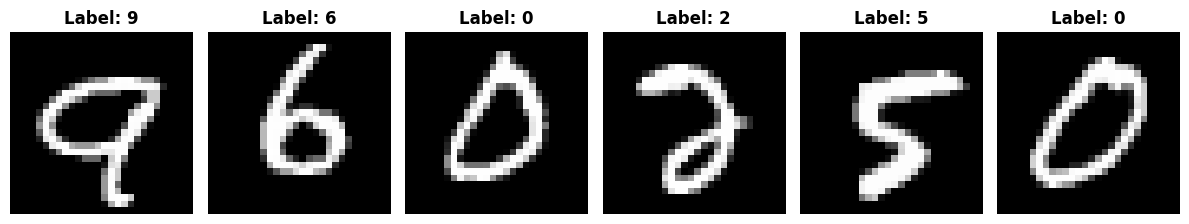

In [3]:
import matplotlib.pyplot as plt

def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        # Skip the first 16 bytes (magic number and dimensions)
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    # Flatten the images to 784 pixels and normalize to [0, 1]
    return data.reshape(-1, 28 * 28) / 255.0

def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        # Skip the first 8 bytes (magic number and item count)
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

print("Loading Local MNIST files from 'archive' directory...")
try:
    X_train = load_mnist_images('archive/train-images.idx3-ubyte')
    y_train = load_mnist_labels('archive/train-labels.idx1-ubyte')

    X_test = load_mnist_images('archive/t10k-images.idx3-ubyte')
    y_test = load_mnist_labels('archive/t10k-labels.idx1-ubyte')

    print("Data loading complete!\n")

    print(f"Training Features Shape: {X_train.shape}")
    print(f"Training Labels Shape: {y_train.shape}\n")

    # Visualize 6 random samples from the dataset
    fig_m, axes_m = plt.subplots(1, 6, figsize=(12, 3))
    # FIXED: Changed X_mnist to X_train to match the loaded variables
    indices = np.random.choice(len(X_train), 6, replace=False)

    for i, ax in enumerate(axes_m):
        idx = indices[i]
        # Reshape the 784 flat array back to 28x28 for plotting
        img = X_train[idx].reshape(28, 28)

        ax.imshow(img, cmap="gray")
        ax.set_title(f"Label: {y_train[idx]}", fontweight="bold")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"ERROR: File not found! Details: {e}")

## Training and Evaluation on MNIST: Hyperparameter Analysis

Now we put our custom Object-Oriented Neural Network to the test using the MNIST dataset. Instead of training a single model, we will run the network under 10 different experimental scenarios to evaluate and compare its capabilities.

We will test the model across various configurations—including L1 and L2 regularization, different initialization methods, extreme batch sizes, dropout rates, and learning rate boundaries. Finally, we will track the performance metrics of each scenario and visualize the comprehensive comparison on a master dashboard.

Initializing 10 Experimental Scenarios...
========== 1. Base ==========
Epoch 001/015 | Average Loss: 0.9173 | Training Accuracy: 80.58%
Epoch 002/015 | Average Loss: 0.5847 | Training Accuracy: 83.82%
Epoch 003/015 | Average Loss: 0.5357 | Training Accuracy: 84.66%
Epoch 004/015 | Average Loss: 0.5146 | Training Accuracy: 84.67%
Epoch 005/015 | Average Loss: 0.5045 | Training Accuracy: 84.86%
Epoch 006/015 | Average Loss: 0.4953 | Training Accuracy: 85.88%
Epoch 007/015 | Average Loss: 0.4886 | Training Accuracy: 85.04%
Epoch 008/015 | Average Loss: 0.4836 | Training Accuracy: 86.31%
Epoch 009/015 | Average Loss: 0.4784 | Training Accuracy: 86.45%
Epoch 010/015 | Average Loss: 0.4753 | Training Accuracy: 85.90%
Epoch 011/015 | Average Loss: 0.4712 | Training Accuracy: 86.48%
Epoch 012/015 | Average Loss: 0.4656 | Training Accuracy: 86.36%
Epoch 013/015 | Average Loss: 0.4617 | Training Accuracy: 86.54%
Epoch 014/015 | Average Loss: 0.4584 | Training Accuracy: 86.83%
Epoch 015/015 | Av

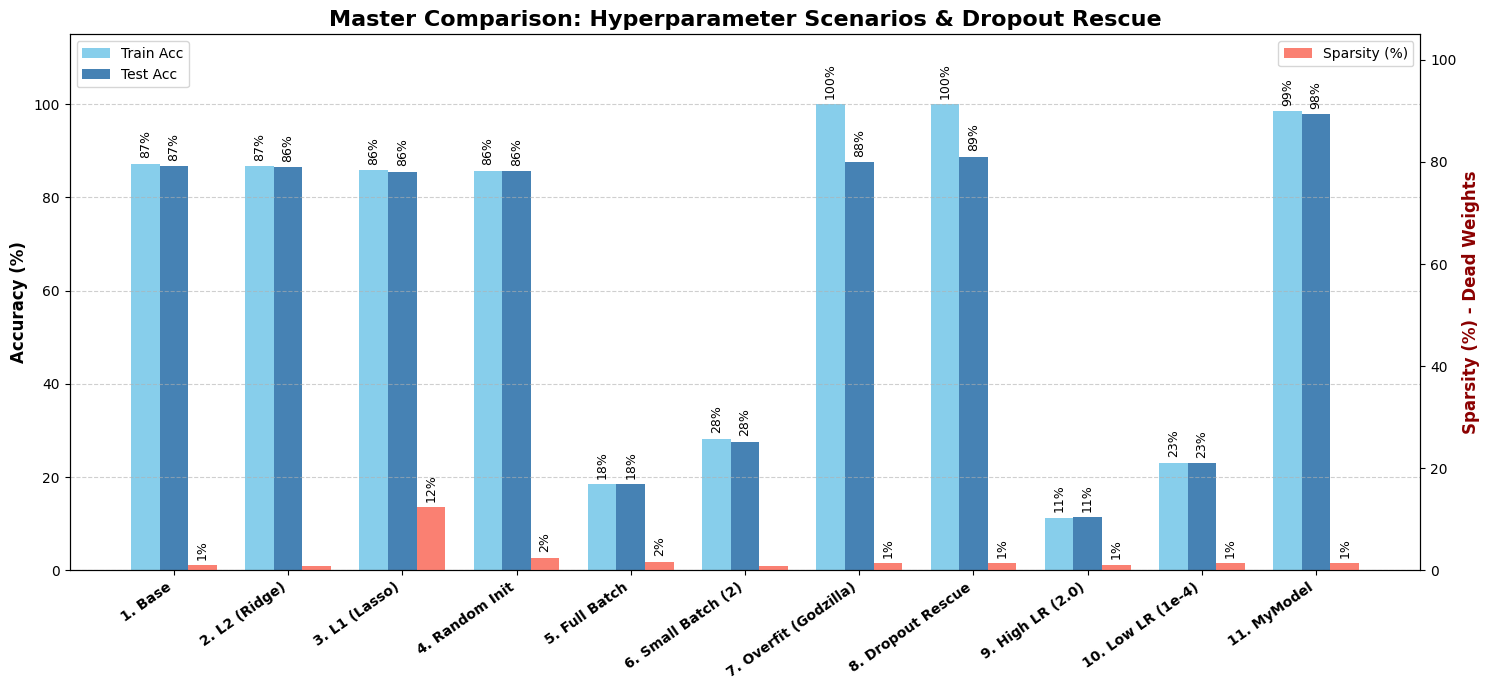

In [5]:
import time

print("Initializing 10 Experimental Scenarios...")

# ==============================================================================
# IMPORTANT NOTE FOR STUDENTS:
# You are highly encouraged to modify the numbers and hyperparameters in these
# scenarios (e.g., number of layers, epochs, learning rate, batch size, etc.)
# to get different results and observe the impact of each parameter.
# The values provided below are not necessarily the "definitive" or "best" ones;
# they simply serve as starting points for your experimentation and comparison.
# ==============================================================================

# 1. Define the 10 Experiments
experiments = {
    "1. Base": {
        "model": NeuralNetwork(hidden_layers=[4], n_classes=10, init_method="he", reg_type=None, drop_rate=0.0),
        "epochs": 15, "lr": 0.1, "bs": 128
    },
    "2. L2 (Ridge)": {
        "model": NeuralNetwork(hidden_layers=[4], n_classes=10, init_method="he", reg_type="l2", reg_lambda=0.005, drop_rate=0.0),
        "epochs": 15, "lr": 0.1, "bs": 128
    },
    "3. L1 (Lasso)": {
        "model": NeuralNetwork(hidden_layers=[4], n_classes=10, init_method="he", reg_type="l1", reg_lambda=0.005, drop_rate=0.0),
        "epochs": 15, "lr": 0.1, "bs": 128
    },
    "4. Random Init": {
        "model": NeuralNetwork(hidden_layers=[4], n_classes=10, init_method="random", reg_type=None, drop_rate=0.0),
        "epochs": 15, "lr": 0.1, "bs": 128
    },
    "5. Full Batch": {
        "model": NeuralNetwork(hidden_layers=[4], n_classes=10, init_method="he", reg_type=None, drop_rate=0.0),
        "epochs": 15, "lr": 0.1, "bs": None
    },
    "6. Small Batch (2)": {
        "model": NeuralNetwork(hidden_layers=[4], n_classes=10, init_method="he", reg_type=None, drop_rate=0.0),
        "epochs": 15, "lr": 0.1, "bs": 2
    },
    "7. Overfit (Godzilla)": {
        "model": NeuralNetwork(hidden_layers=[128], n_classes=10, init_method="he", reg_type=None, drop_rate=0.0),
        "epochs": 100, "lr": 0.1, "bs": 64, "data_limit": 1000
    },
    "8. Dropout Rescue": {
        "model": NeuralNetwork(hidden_layers=[128], n_classes=10, init_method="he", reg_type=None, drop_rate=0.5),
        "epochs": 100, "lr": 0.1, "bs": 64, "data_limit": 1000
    },
    "9. High LR (2.0)": {
        "model": NeuralNetwork(hidden_layers=[4], n_classes=10, init_method="he", reg_type=None, drop_rate=0.0),
        "epochs": 15, "lr": 2.0, "bs": 128
    },
    "10. Low LR (1e-4)": {
        "model": NeuralNetwork(hidden_layers=[4], n_classes=10, init_method="he", reg_type=None, drop_rate=0.0),
        "epochs": 15, "lr": 0.0001, "bs": 128
    },
    "11. MyModel": {
        "model": NeuralNetwork(
            hidden_layers=[128], 
            n_classes=10, 
            init_method="he", 
            reg_type="l2", 
            reg_lambda=0.001, 
            drop_rate=0.15
        ),
        "epochs": 20, 
        "lr": 0.1, 
        "bs": 128
    }
}

results = {}

# 2. Train and Evaluate each model sequentially
for name, config in experiments.items():
    print(f"========== {name} ==========")
    model = config["model"]
    start_time = time.time()

    # Check if we should limit the training data (for Overfitting test)
    limit = config.get("data_limit", len(X_train))
    X_curr_train = X_train[:limit]
    y_curr_train = y_train[:limit]

    # Train
    model.train(
        X_curr_train, y_curr_train,
        epochs=config["epochs"],
        learning_rate=config["lr"],
        batch_size=config["bs"]
    )

    # Evaluate Accuracy (Train accuracy calculated ONLY on the data it saw)
    train_acc = np.mean(model.predict(X_curr_train) == y_curr_train) * 100
    test_acc = np.mean(model.predict(X_test) == y_test) * 100

    # Calculate Sparsity
    total_weights = 0
    zero_weights = 0
    for layer in model.layers:
        if hasattr(layer, 'weights'):
            total_weights += layer.weights.size
            zero_weights += np.sum(np.abs(layer.weights) < 1e-3)

    sparsity = (zero_weights / total_weights) * 100 if total_weights > 0 else 0

    results[name] = {
        "Train Acc": train_acc,
        "Test Acc": test_acc,
        "Sparsity": sparsity
    }

    time_taken = time.time() - start_time
    print(f"-> Done in {time_taken:.1f}s | Train Acc: {train_acc:.1f}% | Test Acc: {test_acc:.1f}%\n")

# 3. Visualize the Massive Comparison
labels = list(results.keys())
train_accs = [results[m]["Train Acc"] for m in labels]
test_accs = [results[m]["Test Acc"] for m in labels]
sparsities = [results[m]["Sparsity"] for m in labels]

x = np.arange(len(labels))
width = 0.25

fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot Accuracies
rects1 = ax1.bar(x - width, train_accs, width, label='Train Acc', color='skyblue')
rects2 = ax1.bar(x, test_accs, width, label='Test Acc', color='steelblue')

ax1.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)
ax1.set_ylim(0, 115)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=35, ha='right', fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Plot Sparsity
ax2 = ax1.twinx()
rects3 = ax2.bar(x + width, sparsities, width, label='Sparsity (%)', color='salmon')
ax2.set_ylabel('Sparsity (%) - Dead Weights', fontweight='bold', color='darkred', fontsize=12)
ax2.set_ylim(0, 105)
ax2.legend(loc='upper right')

# Add text labels on top of bars
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        if height > 1.0:
            ax.annotate(f'{height:.0f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, rotation=90)

autolabel(rects1, ax1)
autolabel(rects2, ax1)
autolabel(rects3, ax2)

plt.title("Master Comparison: Hyperparameter Scenarios & Dropout Rescue", fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

## Results Analysis: Deconstructing Network Behavior

#### **Answer:**

By analyzing the data across the 11 experimental scenarios, we can break down the network's behavior into three main areas:

#### 1. Network Capacity and Architecture
* **The 4-Neuron Bottleneck:** Scenarios 1–4 were heavily limited by using only 4 hidden neurons. Forcing a 784-dimensional input into just 4 neurons created a major information bottleneck. Because the network lacked the capacity to represent complex details, the test accuracy stayed capped around **86–87%** regardless of the optimization settings.
* **Increasing Capacity:** Upgrading the hidden layer to 128 neurons in MyModel gave the network the capacity it needed to learn complex structural features like loops, angles, and curves. This structural change allowed the model to easily break through the previous bottleneck and reach a test accuracy of **97.8%**.

#### 2. Generalization and Regularization
* **The Overfitting Problem (Godzilla):** Scenario 7 demonstrated classic overfitting. Training a large network (128 neurons) on a tiny dataset of 1,000 images for 100 epochs caused it to perfectly memorize the training set (**100% training accuracy**). However, it failed to generalize to new data, dropping to **87.5% test accuracy**. 
* **Regularization Effects:** MyModel successfully resolved this issue by combining Dropout and L2 regularization. Dropout randomly deactivated 15% of the neurons during training to prevent them from relying too heavily on each other, while L2 regularization kept the weight values small and controlled. This closed the generalization gap to just **0.7%**, proving the network learned actual patterns rather than just memorizing the data.
* **Weight Sparsity (L1 Lasso):** Scenario 3 showed that L1 regularization acts as an automatic feature selector, successfully driving **12% of the network weights to exactly zero** by eliminating unhelpful connections.

#### 3. Optimization and Hyperparameters
* **Learning Rate Tuning:** The learning rate determines the step size during weight updates. A high learning rate of 2.0 (Scenario 9) caused the model to overshoot the optimal weights entirely, leaving it stuck at random guessing (~11%). Conversely, a very low learning rate of 1e-4 (Scenario 10) made the updates too small, resulting in slow convergence (~23% after 15 epochs).
* **Batch Size Impact:** Full-batch training (Scenario 5) updated the weights too infrequently (only 15 updates total), leading to poor optimization (~18%). A tiny batch size of 2 (Scenario 6) introduced too much gradient noise, causing the training to stall around 28%. Using a mini-batch size of 128 provided the best balance, offering stable gradients, fast training times, and high accuracy.